# Navigation

Navigation is where an aircraft finds out where it is — and gets it slightly wrong.

That is the whole job. One aircraft, its own sensor, one measurement. Everything downstream inherits
the mistake: the aircraft broadcasts the wrong position, the other aircraft believes it, and the
conflict logic on both sides works from it. The error is applied **once, at the source**, so a
single bad fix corrupts every receiver's picture of that aircraft at the same moment.

## What is actually in the module

Small. One model, four error shapes, one degradation effect, and the values they pass around.

| what | name | in one line |
|---|---|---|
| the model | `GnssNavigation` | measures position and velocity, each with a pluggable error |
| error shape | `gaussian` | round, well-behaved — the default |
| | `make_mixture_gaussian` | round, but with occasional large outliers |
| | `make_anisotropic_gaussian` | an ellipse: worse north–south than east–west |
| | `make_anisotropic_mixture_gaussian` | both at once |
| degradation | `GnssOutage` | a receiver that gets worse, and maybe recovers |
| what it returns | `Message` | the noisy fix, plus the time it was taken |
| what it remembers | `NavState` | anything an effect needs between ticks |
| how bad it is | `NavQuality` | how much worse than nominal, and how much is admitted |
| the interfaces | `NavigationModel`, `NoiseDistribution`, `NavEffect` | for writing your own |

That is the complete list. If you are looking for a bias that grows over time, a multipath model, or
a receiver that loses satellites over a city — none of those ship, and the last section shows how
short they are to write.

In [1]:
%matplotlib inline
import math
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr import AircraftState, geo
from opencdarr.cns import (
    GnssNavigation,
    GnssOutage,
    GnssOutageState,
    NavState,
    gaussian,
    make_anisotropic_gaussian,
    make_anisotropic_mixture_gaussian,
    make_mixture_gaussian,
)
from opencdarr.cns.noise_distributions import CI95_TO_SIGMA

BLUE, RED, ORANGE, PURPLE = "#1f77b4", "#d62728", "#ff7f0e", "#9467bd"
POS_CI95, VEL_CI95 = 20.0, 2.0

TRUE = AircraftState(id="OWN", lat=52.0, lon=4.0, trk=30.0, gs=10.0,
                     pos_ci95=POS_CI95, vel_ci95=VEL_CI95)


def rng(seed: int) -> np.random.Generator:
    return np.random.default_rng(seed)


def error_metres(true: AircraftState, measured: AircraftState) -> float:
    return geo.qdrdist(true.lat, true.lon, measured.lat, measured.lon)[1]


# The handbook page for this module publishes these figures. Written from here rather than redrawn
# by a separate script, so the page and the notebook cannot disagree about a number.
SITE_IMG = Path.home() / "Projects/opencdarr.github.io/docs/assets/img"


def publish(fig, name: str) -> None:
    if SITE_IMG.is_dir():
        fig.savefig(SITE_IMG / f"{name}.png", dpi=130)

## How accurate is it? That is the aircraft's business, not the model's

The obvious design would be `GnssNavigation(accuracy=20.0)`. It is not what happens here, and the
reason is worth a minute.

**Accuracy belongs to the aircraft, not to the model.** A fleet has one navigation model but many
receivers, and they are not equally good. One aircraft might have a survey-grade unit and another a
cheap one; the same aircraft might have a fine fix over open country and a poor one between
buildings. So the two numbers live on `AircraftState`:

- `pos_ci95` — position accuracy in metres
- `vel_ci95` — velocity accuracy in m/s

Both default to `0.0`, which means a perfect sensor. A run with no navigation noise needs no
configuration at all.

In [2]:
nav = GnssNavigation()
message = nav.measure(nav.initial_state(), TRUE, t=5.0, rng=rng(0))

print(f"true position     {TRUE.lat:.6f}, {TRUE.lon:.6f}")
print(f"measured          {message.state.lat:.6f}, {message.state.lon:.6f}")
print(f"off by            {error_metres(TRUE, message.state):.2f} m   (pos_ci95 was {POS_CI95} m)")
print(f"measured at       t = {message.t_meas} s")
print(f"broadcast claims  {message.state.pos_ci95:.0f} m accuracy")

true position     52.000000, 4.000000
measured          51.999990, 4.000015
off by            1.49 m   (pos_ci95 was 20.0 m)
measured at       t = 5.0 s
broadcast claims  20 m accuracy


### What "95%" means, and where the 0.4085 comes from

GNSS accuracy is quoted the way the receiver's datasheet quotes it: a **95% radial CI**. That is the
radius of a circle containing 95 fixes out of 100. It is *not* a standard deviation, and the two
differ by a factor worth knowing.

The error is drawn as a round 2D Gaussian, one draw per axis. The distance from the truth then
follows a Rayleigh distribution, and its 95th percentile sits at $\sigma\sqrt{5.9915}$ — so to hit a
stated 95% radius you use

$$\sigma = \frac{\text{CI95}}{\sqrt{5.9915}} \approx 0.4085 \times \text{CI95}$$

A 20 m accuracy is therefore a per-axis sigma of about 8.2 m. Getting this backwards — treating
CI95 as a sigma — makes the error roughly 2.4 times too big.

In [3]:
draws = np.array([nav.measure(nav.initial_state(), TRUE, 0.0, g).state for g in [rng(1)] * 1
                  for _ in range(8000)])
errs = np.array([geo.qdrdist(TRUE.lat, TRUE.lon, m.lat, m.lon)[1] for m in draws])

print(f"CI95_TO_SIGMA               {CI95_TO_SIGMA:.4f}")
print(f"per-axis sigma  expected    {POS_CI95 * CI95_TO_SIGMA:.2f} m")
print(f"95th pct of the error       {np.quantile(errs, 0.95):.2f} m   (target: {POS_CI95:.0f} m)")
print(f"fraction inside {POS_CI95:.0f} m       {(errs <= POS_CI95).mean():.3f}   (target: 0.95)")

CI95_TO_SIGMA               0.4085
per-axis sigma  expected    8.17 m
95th pct of the error       19.67 m   (target: 20 m)
fraction inside 20 m       0.954   (target: 0.95)


## The four error shapes

The *size* of the error is `pos_ci95`. Its **shape** is a separate choice, and four ship with the
library. Position and velocity take independent ones, because they come from different measurements
inside the same receiver — position from timing the satellite signals, velocity from their Doppler
shift — and there is no reason for them to misbehave together.

| shape | what it looks like | when you would use it |
|---|---|---|
| `gaussian` | a round blob | the default; fine unless you have a reason |
| `make_mixture_gaussian` | round, plus rare far-out points | multipath — signals bouncing off buildings |
| `make_anisotropic_gaussian` | an ellipse, taller than wide | satellite geometry favours one direction |
| `make_anisotropic_mixture_gaussian` | a tall ellipse with outliers | both problems at once |

The ellipse is **axis-aligned, not aligned with the aircraft**. GNSS error is shaped by where the
satellites are, not by which way the aircraft happens to be pointing, so the distribution never sees
the heading.

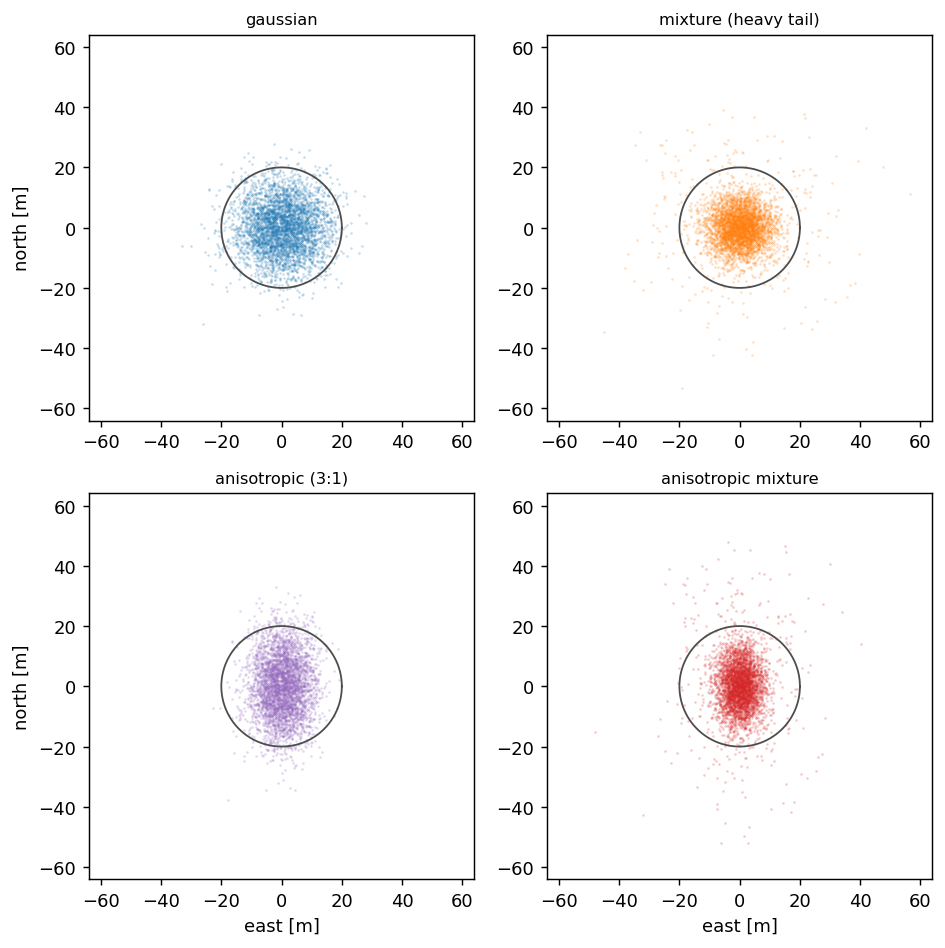

In [4]:
SHAPES = [
    ("gaussian", gaussian, BLUE),
    ("mixture (heavy tail)", make_mixture_gaussian(tail_ratio=3.0, tail_weight=0.1), ORANGE),
    ("anisotropic (3:1)", make_anisotropic_gaussian(var_ratio=3.0), PURPLE),
    ("anisotropic mixture", make_anisotropic_mixture_gaussian(), RED),
]
theta = np.linspace(0.0, 2.0 * np.pi, 200)

fig, axes = plt.subplots(2, 2, figsize=(7.4, 7.4))
for ax, (label, dist, colour) in zip(axes.ravel(), SHAPES):
    pts = np.array([dist(g, POS_CI95) for g in [rng(4)] for _ in range(4000)])
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.25, color=colour, linewidths=0)
    ax.plot(POS_CI95 * np.cos(theta), POS_CI95 * np.sin(theta), color="0.3", lw=1.0)
    ax.set_box_aspect(1)
    ax.set_xlim(-3.2 * POS_CI95, 3.2 * POS_CI95)
    ax.set_ylim(-3.2 * POS_CI95, 3.2 * POS_CI95)
    ax.set_title(label, fontsize=9)
for ax in axes[1]:
    ax.set_xlabel("east [m]")
for ax in axes[:, 0]:
    ax.set_ylabel("north [m]")
fig.tight_layout()
publish(fig, "nav-error-shapes")

The grey circle is `pos_ci95` in all four panels, and **95% of the points fall inside it every
time**. That is the contract the four shapes share: whatever the shape, the advertised number keeps
its meaning. Swapping one for another changes the *character* of the error without changing its
advertised size — which is what makes them comparable.

A single number can describe how big an error is but never what it looks like. That is the entire
reason there is more than one shape.

In [5]:
print(f"{'shape':<24} {'95% inside ci95':>16} {'worst of 20 000':>17}")
for label, dist, _ in SHAPES:
    pts = np.array([dist(g, POS_CI95) for g in [rng(11)] for _ in range(20000)])
    r = np.hypot(pts[:, 0], pts[:, 1])
    print(f"{label:<24} {(r <= POS_CI95).mean():>16.3f} {r.max():>16.1f} m")

shape                     95% inside ci95   worst of 20 000
gaussian                            0.949             40.7 m
mixture (heavy tail)                0.949             67.9 m
anisotropic (3:1)                   0.950             37.1 m
anisotropic mixture                 0.949             79.0 m


The last column is why the shape matters. All four advertise 20 m and all four keep 95% of their
fixes inside it — but the heavy-tailed ones will occasionally put a fix four times further out than
the round one ever does. If your question is "how often does the *unlucky* case bite", the shape is
the whole answer and the CI95 tells you nothing.

## Saying one thing and doing another

A broadcast carries an accuracy figure — the sender telling everyone how much to trust it. By
default that is the truth: the error is drawn from `pos_ci95` and the same number goes on the air.

Setting `pos_ci95_declared` breaks the two apart, which is how you study a sensor that misreports
itself. Two cases, with opposite consequences:

- **Claiming better than reality.** The receiver sizes its safety margin from a confident number
  that is wrong. This is the integrity failure that receiver autonomous integrity monitoring exists
  to catch, and the only case where an aircraft acts confidently on bad data.
- **Claiming worse than reality.** A transmitter derating itself. Receivers are more cautious than
  they need to be — wasteful, not dangerous.

In [6]:
honest = TRUE
liar = replace(TRUE, pos_ci95_declared=5.0)      # 20 m error, claims 5 m

print(f"{'':<14} {'error drawn from':>17} {'broadcast claims':>17} {'actual error':>14}")
for name, source in (("honest", honest), ("over-declares", liar)):
    fix = nav.measure(nav.initial_state(), source, 0.0, rng(3)).state
    print(f"{name:<14} {source.pos_ci95:>17.0f} {fix.pos_ci95:>17.0f}"
          f" {error_metres(source, fix):>13.2f} m")

print("\nSame seed, so both fixes are the same point. Only the claim changed.")

                error drawn from  broadcast claims   actual error
honest                        20                20         26.72 m
over-declares                 20                 5         26.72 m

Same seed, so both fixes are the same point. Only the claim changed.


## A receiver that gets worse: `GnssOutage`

Everything so far assumes the sensor is as good at the end of the flight as at the start. `NavEffect`
is the hook for one that is not, and `GnssOutage` is the only implementation that ships.

It models a receiver losing satellites: the fix gets **worse**, it does not stop. That distinction is
deliberate — an aircraft with a degraded GNSS still broadcasts a position, just a bad one. An
aircraft that stops transmitting altogether is a *radio* failure, and lives on the communication side
as `RadioHealth`.

```python
GnssOutage(
    fail_rate=2.0,       # outages per hour
    recover_rate=0.0,    # per hour; 0 = once it fails, it stays failed
    pos_factor=20.0,     # how many times worse the fix is while degraded
    declare=True,        # does the broadcast admit it?
)
```

Two details that matter more than they look:

**Rates are per hour, not per broadcast.** A mean time to failure of half an hour is half an hour
whether the aircraft transmits at 1 Hz or 2 Hz. Had the rate been per-message, changing the
broadcast cadence would silently change the failure rate too, and a cadence study would be measuring
two things at once.

**`declare` is the interesting switch.** `True` is an honest transponder derating itself, so
receivers widen their margins and behave sensibly. `False` is the fix going bad while the broadcast
keeps claiming nominal — the case that actually hurts, because now everyone is confidently wrong.

OWN    degraded 23.2% of the time
OTHER  degraded 96.0% of the time


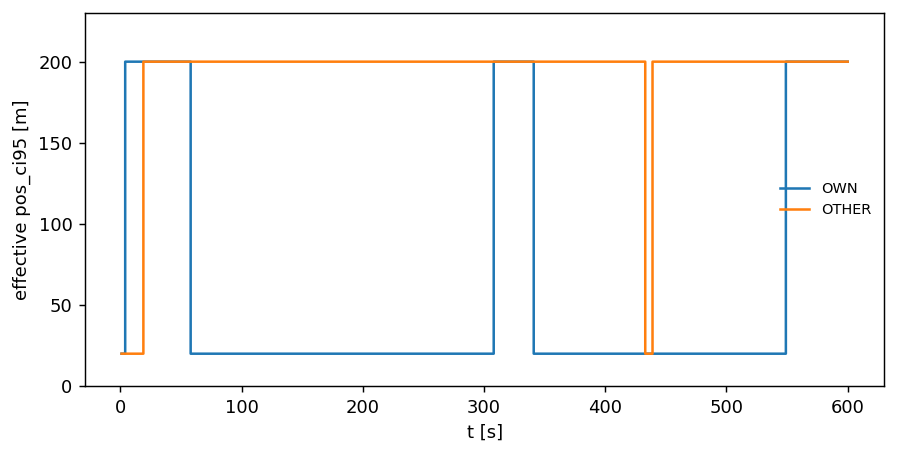

In [7]:
# rates are per hour; these are ~90 s of good fix then ~145 s of bad, so a 10-minute
# flight shows a few cycles. A realistic rate would show nothing in 10 minutes at all.
outage = GnssOutage(fail_rate=40.0, recover_rate=25.0, pos_factor=10.0)
fleet = [TRUE, replace(TRUE, id="OTHER")]

state, t, dt = outage.initial(), 0.0, 1.0
times, degraded = [], {ac.id: [] for ac in fleet}
g = rng(7)
for _ in range(600):
    state = outage.evolve(state, fleet, dt, g)
    t += dt
    times.append(t)
    for ac in fleet:
        q = outage.quality(state, ac.id)
        degraded[ac.id].append(POS_CI95 * q.pos_scale)

fig, ax = plt.subplots(figsize=(7.0, 3.6))
for (ac_id, series), colour in zip(degraded.items(), (BLUE, ORANGE)):
    ax.step(times, series, where="post", lw=1.4, color=colour, label=ac_id)
ax.set_xlabel("t [s]")
ax.set_ylabel("effective pos_ci95 [m]")
ax.set_ylim(0, 1.15 * POS_CI95 * outage.pos_factor)
ax.legend(frameon=False, fontsize=8, loc="center right")
fig.tight_layout()
publish(fig, "nav-outage")

for ac_id, series in degraded.items():
    frac = np.mean(np.array(series) > POS_CI95)
    print(f"{ac_id:<6} degraded {frac:.1%} of the time")

Each aircraft fails and recovers on its own — the two lines are independent, because two receivers
have no reason to lose satellites together. With `recover_rate=0` (the default) the step up would
never come back down: the outage latches for the rest of the flight.

!!! note
    A rare outage is exactly the wrong shape for the rare-event estimator. It is a sudden jump, and
    minimum separation carries no clue about whether it has happened, so the splitting shells cannot
    steer toward it. Study outages with plain Monte Carlo.

## Why the model has two methods

`NavigationModel` asks for `measure`, and offers `evolve`. The split confuses people, so:

| | `evolve` | `measure` |
|---|---|---|
| runs | once per tick, for every aircraft | once per aircraft that is transmitting |
| may | change what the model remembers | only read it |
| gives back | the updated memory | the `Message` |

**Everything that changes state goes in `evolve`.** The reason is reproducibility. Only some
aircraft transmit on any given tick, so if `measure` advanced the state, the number of random draws
taken would depend on *who happened to transmit* — and changing the broadcast schedule would shift
every later random number. Running the state advance once per tick, regardless of who fires, keeps
the draws in a fixed place.

If your model is stateless, ignore `evolve` entirely: the default does nothing and draws nothing.

## Writing your own

### An error shape

A shape is any function taking a generator and an accuracy, returning an east/north error in metres.
Not a class, not a subclass — a function.

In [8]:
def uniform_disk(g: np.random.Generator, ci95: float) -> tuple[float, float]:
    # error uniform inside a disc, sized so 95% of it falls within ci95
    radius = ci95 / math.sqrt(0.95)
    r = radius * math.sqrt(g.random())
    a = g.uniform(0.0, 2.0 * math.pi)
    return r * math.cos(a), r * math.sin(a)


pts = np.array([uniform_disk(g, POS_CI95) for g in [rng(5)] for _ in range(20000)])
inside = (np.hypot(pts[:, 0], pts[:, 1]) <= POS_CI95).mean()
print(f"fraction inside ci95: {inside:.3f}   (aiming for 0.95)")

mine = GnssNavigation(pos_distribution=uniform_disk)
print(f"one fix with it: off by {error_metres(TRUE, mine.measure(mine.initial_state(), TRUE, 0.0, rng(2)).state):.2f} m")

fraction inside ci95: 0.951   (aiming for 0.95)
one fix with it: off by 10.50 m


One rule to follow: **draw the same number of times whatever the accuracy is**, including when it is
zero. If a shape short-circuits at `ci95 == 0` and skips its draws, every later random number in that
run shifts, and a sweep over `pos_ci95` stops being a controlled comparison. Scaling the output by
zero costs nothing; skipping the draw costs correctness.

### A degradation effect

Three methods: what the state starts as, how it advances, and what it means for one aircraft. The
same rule applies — draw a fixed number of times, whatever the parameters, including zero.

Return a `NavQuality` saying how much worse the fix is (`pos_scale`) and how much of that the
broadcast admits to (`pos_declared`). Both at `1.0` means nothing has gone wrong.

## Where the fix goes next

The `Message` this module produces is handed straight to
[communication](https://opencdarr.github.io/modules/cns/communication/), which decides whether it
arrives and how late, then to
[surveillance](https://opencdarr.github.io/modules/cns/surveillance/), which decides what a receiver
believes in between deliveries. What comes out the far end is the only view the conflict logic ever
gets.

The outcome of a run, though, is scored on the **true** states. Navigation error changes what the
aircraft *do*; it never changes what is measured of them.